# **Análisis de grandes volúmenes de datos (TC4034)**

## Maestría en Inteligencia Artificial Aplicada
### Ivan Olmos Pineda | Perla A. García Aguirre
### Tecnológico de Monterrey
## **Proyecto | lectura, escritura, archivos de Big Data PySpark**

---

### Team 8

- Michelle Andrea Arceo Solano — A01625268
- Jacobo Daniel Salazar García — A01796997
- Ariel Antonio Alvarez Monroy — A01796838
- Omar Aguilar Macedo - A0179707

# Descripción del proyecto

## NYC Taxi Trip Records

## Contexto del Dataset

El dataset **NYC Taxi Trip Records** contiene información detallada sobre los viajes realizados por taxis en la ciudad de Nueva York. Cada registro representa un viaje individual e incluye variables relacionadas con tiempo, ubicación, distancia y costo del servicio.

Este dataset es ampliamente utilizado en proyectos de Big Data debido a su gran volumen, riqueza de variables y aplicabilidad en análisis de patrones urbanos, predicción y segmentación.

| Atributo         | Detalle |
|------------------|---------|
| **Nombre**       | NYC Yellow Taxi Trip Data |
| **Origen**       | Taxi & Limousine Commission (TLC) — NYC Government |
| **Fuente oficial**| https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page |
| **Diccionario de datos**| https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf |
| **Tabla de zonas (lookup)**| https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv |
| **Período a analizar**      | Enero 2023 — Marzo 2026 |
| **Tamaño total** | ~2.5 GB (139,279,754 registros, 24 columnas) |
| **Tamaño por archivo mensual** | ~45MB - 70MB (Parquet)   |
| **Formato**      | parquet |




## Tipos de Datos Disponibles

El dataset está dividido en diferentes categorías según el tipo de servicio:

- Yellow Taxi Trips  
- Green Taxi Trips  
- For-Hire Vehicle (FHV) Trips  
- High Volume FHV (Uber, Lyft, etc.)

Para este proyecto se seleccionó: **Yellow Taxi Trips**

## Formato y Acceso

Los datos están disponibles en formato `Parquet`

Este formato resulta eficiente, ya que se puede comprimir, permite lectura de columnas, y tiene un mejor rendimiento al usarse con PySpark

Ejemplo de archivo:
- https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet

## Variables Principales

Algunas de las variables más relevantes incluyen:

- `tpep_pickup_datetime`: inicio del viaje  
- `tpep_dropoff_datetime`: fin del viaje  
- `trip_distance`: distancia recorrida  
- `fare_amount`: costo del viaje  
- `tip_amount`: propina  
- `payment_type`: tipo de pago  
- `PULocationID`: zona de origen  
- `DOLocationID`: zona de destino  

## Preprocesamiento y Tipado

Posterior a la lectura del dataset en formato Parquet, se realizó una etapa de transformación en la cual se ajustaron los tipos de datos de ciertas columnas con el objetivo de optimizar su almacenamiento y facilitar su uso en etapas posteriores del análisis.

Esta transformación incluyó la conversión de variables categóricas a tipos numéricos compactos y la reducción de precisión en variables numéricas cuando fue apropiado. Posteriormente, el dataset transformado fue almacenado nuevamente en formato Parquet, generando una versión limpia y estructurada del conjunto de datos.

Este enfoque permite separar claramente la capa de datos originales de la capa de datos procesados, siguiendo buenas prácticas en el manejo de datos a gran escala.

```python
df_clean = df.select(
    # Categórica, TPEP Provider, son pocas opciones, Byte debería basta
    F.col("VendorID").cast(T.ByteType()),
    # dejaremos las fechas como estan
    F.col("tpep_pickup_datetime"),
    # dejaremos las fechas como estan
    F.col("tpep_dropoff_datetime"),
    # Byte debe ser suficiente, no hay taxis con más de 127 asientos
    F.col("passenger_count").cast(T.ByteType()),
    # La distancia en millas no necesita tener tanta precision
    # y Float debe ser suficiente
    F.col("trip_distance").cast(T.FloatType()),
    # RateCode es categórica el valor máximo es 99
    F.col("RatecodeID").cast(T.ByteType()),
    # Store and forward: 'Y' o 'N'
    F.col("store_and_fwd_flag"),
    # ID de Zona de inicio del viaje
    F.col("PULocationID").cast(T.ShortType()),
    # ID de Zona de destino del viaje
    F.col("DOLocationID").cast(T.ShortType()),
    # Categórica, valor máximo 7
    F.col("payment_type").cast(T.ByteType()),
    # Monto del viaje, no es necesario tanta precisión como un double
    F.col("fare_amount").cast(T.FloatType()),
    # Cobros extra, no necesita tanta precisión como un double
    F.col("extra").cast(T.FloatType()),
    # Impuesto, no necesita tanta precisión como un double
    F.col("mta_tax").cast(T.FloatType()),
    # Propina, no necesita tanta precisión como un double
    F.col("tip_amount").cast(T.FloatType()),
    # Cobros por peaje, no necesita la precisión de un double
    F.col("tolls_amount").cast(T.FloatType()),
    # Cobros para mejoras por parte del estado, no necesita un double.
    F.col("improvement_surcharge").cast(T.FloatType()),
    # Cantidad total del viaje, no necesita ser double
    F.col("total_amount").cast(T.FloatType()),
    # Cobros por tráfico pesado, no necesita un double
    F.col("congestion_surcharge").cast(T.FloatType()),
    # Cuotas aeropuertarias, no necesita un double
    F.col("Airport_fee").cast(T.FloatType()),
)
```

## Calidad de los Datos

Durante la exploración se identificaron:

- valores nulos en algunas columnas
- presencia de valores atípicos (por ejemplo en las fechas)
- inconsistencias en algunos registros  
- variables codificadas que requieren interpretación adicional  


## Trabajo Futuro

- técnicas de muestreo y particionamiento  
- modelos de aprendizaje automático  
- comparación con servicios de ride-sharing  

## Recursos

- Código: https://github.com/ArielAlvarezWAI87/BigData
- Datos: https://drive.google.com/drive/u/1/folders/1RFRCAy3gFOuO9nzmJpf49lhQDTKSNWNf

El dataset no se incluye directamente en el repositorio debido a su tamaño, pero se proporciona acceso mediante almacenamiento externo.

## Selección del dataset

Para este proyecto se revisaron tres posibles datasets: **Amazon Reviews**, **Airline Flight Delays** y **NYC Taxi Trip Records**.

El dataset de **Amazon Reviews** fue descartado porque, aunque tiene un gran volumen de información, requiere procesamiento de texto y técnicas de NLP, lo cual aumentaba la complejidad del proyecto. El dataset de **Airline Flight Delays** también era una opción viable por su estructura tabular, pero su análisis se enfoca principalmente en retrasos de vuelos, por lo que ofrecía menor variedad de análisis.

Finalmente, se seleccionó el dataset **NYC Yellow Taxi Trip Records**, ya que cumple mejor con los criterios del proyecto: tiene un alto volumen de datos, una estructura tabular, una fuente oficial y variables útiles para analizar movilidad urbana, como fechas de viaje, zonas de origen y destino, distancia, tarifa, propina y número de pasajeros.

Además, este dataset permite trabajar de forma práctica con PySpark, ya que facilita el análisis exploratorio, la revisión de calidad de datos, el procesamiento distribuido y la generación de visualizaciones temporales y geográficas.

# Preparación del entorno

In [1]:
# @title Dataset Imports
import os
import requests
from pathlib import Path

In [2]:
# @title Conectar a google drive
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [3]:
#@title Validación de Java
!java --version
!which java

openjdk 17.0.18 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
/usr/bin/java


In [4]:
#@title Agregamos JAVA_HOME

# Solo para linux :S, por lo que funciona en colab
JAVA_HOME=!java -XshowSettings:properties -version 2>&1 > /dev/null | grep 'java.home' | awk '{print $NF}'
JAVA_HOME=JAVA_HOME[0] # El comando anterior regresa un arreglo
%env JAVA_HOME=$JAVA_HOME

env: JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64


In [5]:
#@title Configuración e instalación de PySpark
!pip install pyspark
!pip install findspark

In [6]:
#@title PySpark imports
import findspark
from pyspark.sql import SparkSession

from pyspark.sql import functions as F
from pyspark.sql import types as T
from functools import reduce
import glob

# Para cargar algunos datasets estadísticos simples
import pandas as pd

# Para crear graficos simples
import matplotlib.pyplot as plt

# Descarga y lectura del dataset

In [7]:
# @title Dataset Utils

BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"

def taxi_file_url(taxi_type: str, year: int, month: int) -> str:
    """
    taxi_type:
      - yellow
      - green
      - fhv
      - fhvhv
    """
    return f"{BASE_URL}/{taxi_type}_tripdata_{year}-{month:02d}.parquet"


def download_taxi_data(
    taxi_type: str,
    years_months: list[tuple[int, int]],
    output_dir: str = "/content/data/taxi",
    overwrite: bool = False
):
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    downloaded_files = []

    for year, month in years_months:
        url = taxi_file_url(taxi_type, year, month)
        filename = url.split("/")[-1]
        output_path = Path(output_dir) / filename

        if output_path.exists() and not overwrite:
            print(f"Already exists: {output_path}")
            downloaded_files.append(str(output_path))
            continue

        print(f"Downloading: {url}")

        response = requests.get(url, stream=True, timeout=120)

        if response.status_code != 200:
            print(f"Could not download {url} - status {response.status_code}")
            continue

        with open(output_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

        print(f"Saved: {output_path}")
        downloaded_files.append(str(output_path))

    return downloaded_files

In [8]:
drive_dir = '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow'

In [9]:
# año 2023 completo
months = [(2023, m) for m in range(1, 13)]

files = download_taxi_data(
    taxi_type="yellow",
    years_months=months,
    output_dir=drive_dir
)

files


Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-01.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-02.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-03.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-04.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-05.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-06.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-07.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-08.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-09.parquet
A

['/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-01.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-02.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-03.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-04.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-05.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-06.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-07.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-08.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-09.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2023-10.parquet',
 '/content

In [10]:
# año 2024 completo
months = [(2024, m) for m in range(1, 13)]

files = download_taxi_data(
    taxi_type="yellow",
    years_months=months,
    output_dir=drive_dir
)

files


Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-01.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-02.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-03.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-04.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-05.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-06.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-07.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-08.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-09.parquet
A

['/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-01.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-02.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-03.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-04.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-05.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-06.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-07.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-08.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-09.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2024-10.parquet',
 '/content

In [11]:
# año 2025 completo
months = [(2025, m) for m in range(1, 13)]

files = download_taxi_data(
    taxi_type="yellow",
    years_months=months,
    output_dir=drive_dir
)

files

Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-01.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-02.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-03.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-04.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-05.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-06.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-07.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-08.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-09.parquet
A

['/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-01.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-02.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-03.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-04.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-05.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-06.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-07.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-08.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-09.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2025-10.parquet',
 '/content

In [12]:
# 2026 de enero a marzo
months = [(2026, m) for m in range(1, 4)]

files = download_taxi_data(
    taxi_type="yellow",
    years_months=months,
    output_dir=drive_dir
)

files

Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2026-01.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2026-02.parquet
Already exists: /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2026-03.parquet


['/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2026-01.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2026-02.parquet',
 '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/yellow_tripdata_2026-03.parquet']

In [13]:
#@title Leer el dataset
# findspark.init()

spark = (
    SparkSession.builder
    .appName("NYC Yellow Taxi")
    .getOrCreate()
)

parquet_files = glob.glob(f"{drive_dir}/*.parquet")

print(f"Archivos encontrados: {len(parquet_files)}")

dfs = []

for file in parquet_files:
    temp_df = spark.read.parquet(file)

    # Homologar tipos de datos entre archivos
    temp_df = temp_df.withColumn("passenger_count", F.col("passenger_count").cast("double")) \
                     .withColumn("RatecodeID", F.col("RatecodeID").cast("double")) \
                     .withColumn("VendorID", F.col("VendorID").cast("int")) \
                     .withColumn("PULocationID", F.col("PULocationID").cast("int")) \
                     .withColumn("DOLocationID", F.col("DOLocationID").cast("int")) \
                     .withColumn("payment_type", F.col("payment_type").cast("double")) \
                     .withColumn("trip_distance", F.col("trip_distance").cast("double")) \
                     .withColumn("fare_amount", F.col("fare_amount").cast("double")) \
                     .withColumn("tip_amount", F.col("tip_amount").cast("double")) \
                     .withColumn("total_amount", F.col("total_amount").cast("double"))

    dfs.append(temp_df)

# Unir todos los archivos ya homologados
df = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs)

df.printSchema()

# df = spark.read.parquet(
#     f"{drive_dir}/yellow_tripdata_2025-10.parquet",
#     f"{drive_dir}/yellow_tripdata_2025-11.parquet",
#     f"{drive_dir}/yellow_tripdata_2025-12.parquet",
#     f"{drive_dir}/yellow_tripdata_2026-01.parquet",
#     f"{drive_dir}/yellow_tripdata_2026-02.parquet",
#     f"{drive_dir}/yellow_tripdata_2026-03.parquet",
# )

Archivos encontrados: 39
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



# Preprocesamiento

In [14]:
#@title Crear columnas derivadas

df = df.withColumn("pickup_year", F.year("tpep_pickup_datetime")) \
       .withColumn("pickup_month", F.month("tpep_pickup_datetime")) \
       .withColumn("pickup_hour", F.hour("tpep_pickup_datetime")) \
       .withColumn(
           "trip_duration_minutes",
           (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60
       )

## Dataset Transformado

El siguiente bloque documenta la transformación de tipos aplicada al dataset original para reducir el uso de memoria. Este paso fue ejecutado en una sesión previa y el resultado se encuentra almacenado en Google Drive en la carpeta `clean/`.

**El código se conserva comentado como referencia técnica.** Para regenerar el dataset limpio, descomenta las celdas 23 y 24 y ejecútalas una sola vez antes de continuar con el análisis.

> Ruta del dataset limpio: `{drive_dir}/clean/`

In [15]:
# # Transformamos los tipos de datos basados en el diccionario de datos del dataset

# NOTA: Esta celda está comentada intencionalmente.
# El dataset transformado ya fue generado y almacenado en Drive.
# Descomentar solo si se necesita regenerar desde cero.

# df_clean = df.select(
#     # Categórica, TPEP Provider, son pocas opciones, Byte debería basta
#     F.col("VendorID").cast(T.ByteType()),
#     # dejaremos las fechas como estan
#     F.col("tpep_pickup_datetime"),
#     # dejaremos las fechas como estan
#     F.col("tpep_dropoff_datetime"),
#     # Byte debe ser suficiente, no hay taxis con más de 127 asientos
#     F.col("passenger_count").cast(T.ByteType()),
#     # La distancia en millas no necesita tener tanta precision
#     # y Float debe ser suficiente
#     F.col("trip_distance").cast(T.FloatType()),
#     # RateCode es categórica el valor máximo es 99
#     F.col("RatecodeID").cast(T.ByteType()),
#     # Store and forward: 'Y' o 'N'
#     F.col("store_and_fwd_flag"),
#     # ID de Zona de inicio del viaje
#     F.col("PULocationID").cast(T.ShortType()),
#     # ID de Zona de destino del viaje
#     F.col("DOLocationID").cast(T.ShortType()),
#     # Categórica, valor máximo 7
#     F.col("payment_type").cast(T.ByteType()),
#     # Monto del viaje, no es necesario tanta precisión como un double
#     F.col("fare_amount").cast(T.FloatType()),
#     # Cobros extra, no necesita tanta precisión como un double
#     F.col("extra").cast(T.FloatType()),
#     # Impuesto, no necesita tanta precisión como un double
#     F.col("mta_tax").cast(T.FloatType()),
#     # Propina, no necesita tanta precisión como un double
#     F.col("tip_amount").cast(T.FloatType()),
#     # Cobros por peaje, no necesita la precisión de un double
#     F.col("tolls_amount").cast(T.FloatType()),
#     # Cobros para mejoras por parte del estado, no necesita un double.
#     F.col("improvement_surcharge").cast(T.FloatType()),
#     # Cantidad total del viaje, no necesita ser double
#     F.col("total_amount").cast(T.FloatType()),
#     # Cobros por tráfico pesado, no necesita un double
#     F.col("congestion_surcharge").cast(T.FloatType()),
#     # Cuotas aeropuertarias, no necesita un double
#     F.col("Airport_fee").cast(T.FloatType()),
# )

In [16]:
# Guardamos el dataframe ya creado
# df_clean.write.mode("overwrite").parquet(f"{drive_dir}/clean")

# Revisión inicial del dataset


In [17]:
#@title Dimensiones generales

total_records = df.count()
total_columns = len(df.columns)
size_in_bytes = df._jdf.queryExecution().optimizedPlan().stats().sizeInBytes()
print(f"Número de registros: {total_records:,}")
print(f"Información de columnas: {total_columns}")
print(f"Tamaño aproximado: ~{(size_in_bytes / 1024 / 1024 / 1024):.02f} GB")


Número de registros: 139,279,754
Información de columnas: 24
Tamaño aproximado: ~2.51 GB


In [18]:
#@title Esquema del dataset

df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-- pickup_year: integer (nullable = true)
 |-- pickup_month: integer

In [19]:
#@title Muestra 10 registros
df.limit(10).toPandas()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2.0,...,0.0,1.0,14.30,2.5,0.00,NaN,2023,1,0,8.433333
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1.0,...,0.0,1.0,16.90,2.5,0.00,NaN,2023,1,0,6.316667
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1.0,...,0.0,1.0,34.90,2.5,0.00,NaN,2023,1,0,12.750000
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1.0,...,0.0,1.0,20.85,0.0,1.25,NaN,2023,1,0,9.616667
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1.0,...,0.0,1.0,19.68,2.5,0.00,NaN,2023,1,0,10.833333
5,2,2023-01-01 00:50:34,2023-01-01 01:02:52,1.0,1.84,1.0,N,161,137,1.0,...,0.0,1.0,27.80,2.5,0.00,NaN,2023,1,0,12.300000
6,2,2023-01-01 00:09:22,2023-01-01 00:19:49,1.0,1.66,1.0,N,239,143,1.0,...,0.0,1.0,20.52,2.5,0.00,NaN,2023,1,0,10.450000
7,2,2023-01-01 00:27:12,2023-01-01 00:49:56,1.0,11.70,1.0,N,142,200,1.0,...,3.0,1.0,64.44,2.5,0.00,NaN,2023,1,0,22.733333
8,2,2023-01-01 00:21:44,2023-01-01 00:36:40,1.0,2.95,1.0,N,164,236,1.0,...,0.0,1.0,28.38,2.5,0.00,NaN,2023,1,0,14.933333
9,2,2023-01-01 00:39:42,2023-01-01 00:50:36,1.0,3.01,1.0,N,141,107,2.0,...,0.0,1.0,19.90,2.5,0.00,NaN,2023,1,0,10.900000


# Revisión de calidad de datos

In [20]:
#@title Conteo de Nans y Nulls
nan_compatible_types = ("double", "float")

df.select([
    F.count(F.when(
        (F.isnan(c) if t in nan_compatible_types else F.lit(False)) | F.col(c).isNull(),
        c
    )).alias(c)
    for c, t in df.dtypes
]).limit(1).toPandas()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes
0,0,0,0,20069605,0,20069605,20069605,0,0,0,...,0,0,0,20069605,20069605,79479946,0,0,0,0


In [21]:
#@title Registros por mes
# se notan algunos errores, por ejemplo:
# registros de junio 2026, lo cual no ha ocurrido
df.groupBy(
    F.year("tpep_pickup_datetime").alias('year'),
    F.month("tpep_pickup_datetime").alias('month')
  ) \
  .count() \
  .orderBy('year', 'month') \
  .show(50)

+----+-----+-------+
|year|month|  count|
+----+-----+-------+
|2001|    1|      6|
|2002|   12|     22|
|2003|    1|      6|
|2007|   12|      1|
|2008|   12|     35|
|2009|    1|     40|
|2014|   11|      1|
|2022|   10|     11|
|2022|   12|     25|
|2023|    1|3066726|
|2023|    2|2914003|
|2023|    3|3403660|
|2023|    4|3288248|
|2023|    5|3513664|
|2023|    6|3307259|
|2023|    7|2907093|
|2023|    8|2824201|
|2023|    9|2846741|
|2023|   10|3522269|
|2023|   11|3339731|
|2023|   12|3376537|
|2024|    1|2964623|
|2024|    2|3007533|
|2024|    3|3582611|
|2024|    4|3514295|
|2024|    5|3723843|
|2024|    6|3539170|
|2024|    7|3076876|
|2024|    8|2979192|
|2024|    9|3633025|
|2024|   10|3833780|
|2024|   11|3646372|
|2024|   12|3668371|
|2025|    1|3475236|
|2025|    2|3577543|
|2025|    3|4145231|
|2025|    4|3970568|
|2025|    5|4591844|
|2025|    6|4322949|
|2025|    7|3898971|
|2025|    8|3574080|
|2025|    9|4251019|
|2025|   10|4428708|
|2025|   11|4181432|
|2025|   12|4

In [22]:
# Filtro para revision detallado de registros
df.filter(
    (F.year(F.col("tpep_pickup_datetime")) == 2026)
    & (F.month(F.col("tpep_pickup_datetime")) == 6)
).limit(10).toPandas()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes
0,2,2026-06-26 23:26:55,2026-06-26 23:47:51,1.0,10.96,1.0,N,138,233,1.0,...,6.94,1.0,73.07,2.5,1.75,NaN,2026,6,23,20.933333
1,2,2026-06-26 23:53:12,2026-06-27 20:59:10,1.0,0.56,1.0,N,233,264,1.0,...,0.00,1.0,13.50,2.5,0.00,NaN,2026,6,23,1265.966667


In [23]:
#@title Valores inválidos y posibles outliers
# Permite identificar registros que podrían afectar el análisis, como:
# - viajes con distancia cero
# - tarifas negativas
# - duración inválida
# - número de pasajeros fuera de lo esperado.
quality_summary = df.select(
    F.count("*").alias("total_records"),
    F.sum(F.when(F.col("trip_distance") <= 0, 1).otherwise(0)).alias("zero_or_negative_distance"),
    F.sum(F.when(F.col("fare_amount") <= 0, 1).otherwise(0)).alias("zero_or_negative_fare"),
    F.sum(F.when(F.col("passenger_count") <= 0, 1).otherwise(0)).alias("zero_or_negative_passengers"),
    F.sum(F.when(F.col("trip_duration_minutes") <= 0, 1).otherwise(0)).alias("zero_or_negative_duration")
)

quality_summary.show()

+-------------+-------------------------+---------------------+---------------------------+-------------------------+
|total_records|zero_or_negative_distance|zero_or_negative_fare|zero_or_negative_passengers|zero_or_negative_duration|
+-------------+-------------------------+---------------------+---------------------------+-------------------------+
|    139279754|                  3322918|              4107385|                    1285059|                   710184|
+-------------+-------------------------+---------------------+---------------------------+-------------------------+



# Estadísticas generales

In [24]:
#@title Estadísticas simples
numeric_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "trip_duration_minutes"
]

df.select(numeric_cols).describe().show()

+-------+------------------+-----------------+------------------+-----------------+------------------+---------------------+
|summary|   passenger_count|    trip_distance|       fare_amount|       tip_amount|      total_amount|trip_duration_minutes|
+-------+------------------+-----------------+------------------+-----------------+------------------+---------------------+
|  count|         119210149|        139279754|         139279754|        139279754|         139279754|            139279754|
|   mean| 1.326900321213423|5.484180360771792|19.198813160455117|3.156146757266609|27.838543955711717|    17.21884786918378|
| stddev|0.8058137360054483|496.0968770771867|102.39004514794563|4.059580103288303|103.34115835174282|     2393.82175073862|
|    min|               0.0|              0.0|           -2555.2|           -411.0|           -2560.2| -2.82482984666666...|
|    max|               9.0|        398608.62|         863372.12|           4174.0|         863380.37|   14880.766666666666|


In [25]:
#@title Variables categóricas

df.groupBy('store_and_fwd_flag').count().orderBy('count', ascending=False).show()
df.groupBy('VendorID').count().orderBy('VendorID').show()
df.groupBy('RatecodeID').count().orderBy('RatecodeID').show()
df.groupBy('payment_type').count().orderBy('payment_type').show()

+------------------+---------+
|store_and_fwd_flag|    count|
+------------------+---------+
|                 N|118690941|
|              NULL| 20069605|
|                 Y|   519208|
+------------------+---------+

+--------+---------+
|VendorID|    count|
+--------+---------+
|       1| 31452963|
|       2|107103127|
|       6|    53791|
|       7|   669873|
+--------+---------+

+----------+---------+
|RatecodeID|    count|
+----------+---------+
|      NULL| 20069605|
|       1.0|111107673|
|       2.0|  4426390|
|       3.0|   442355|
|       4.0|   318991|
|       5.0|  1078541|
|       6.0|      196|
|      99.0|  1836003|
+----------+---------+

+------------+--------+
|payment_type|   count|
+------------+--------+
|         0.0|20069605|
|         1.0|98273329|
|         2.0|17540692|
|         3.0|  882619|
|         4.0| 2513500|
|         5.0|       9|
+------------+--------+



## Variables principales

Después de homologar los tipos de datos y crear columnas derivadas, el dataset quedó estructurado con variables originales del registro de viaje y variables adicionales para facilitar el análisis temporal.

| Variable | Tipo de dato | Descripción | Uso en el análisis |
|---|---|---|---|
| `VendorID` | integer | Identificador del proveedor que registró el viaje | Revisión por proveedor o fuente de registro |
| `tpep_pickup_datetime` | timestamp | Fecha y hora de inicio del viaje | Base para análisis temporal |
| `tpep_dropoff_datetime` | timestamp | Fecha y hora de fin del viaje | Cálculo de duración del viaje |
| `passenger_count` | double | Número de pasajeros reportados en el viaje | Análisis de demanda y validación de valores atípicos |
| `trip_distance` | double | Distancia recorrida durante el viaje | Análisis de distancia, tarifas y outliers |
| `RatecodeID` | double | Código de tarifa aplicado al viaje | Segmentación por tipo de tarifa |
| `store_and_fwd_flag` | string | Indica si el registro fue almacenado antes de enviarse al sistema | Revisión técnica de origen del registro |
| `PULocationID` | integer | Identificador de la zona de origen del viaje | Análisis geográfico de puntos de salida |
| `DOLocationID` | integer | Identificador de la zona de destino del viaje | Análisis geográfico de destinos |
| `payment_type` | double | Tipo de método de pago utilizado | Análisis de comportamiento de pago |
| `fare_amount` | double | Tarifa base del viaje | Análisis económico del servicio |
| `extra` | double | Cargos adicionales aplicados al viaje | Revisión de componentes del costo |
| `mta_tax` | double | Impuesto MTA aplicado | Revisión de componentes regulatorios del costo |
| `tip_amount` | double | Propina registrada | Análisis de propinas y comportamiento del usuario |
| `tolls_amount` | double | Monto pagado en peajes | Análisis de costos adicionales |
| `improvement_surcharge` | double | Cargo de mejora aplicado al viaje | Revisión de cargos fijos adicionales |
| `total_amount` | double | Monto total cobrado al pasajero | Análisis del costo total del viaje |
| `congestion_surcharge` | double | Cargo por congestión aplicado en ciertas zonas | Análisis de costos asociados a ubicación |
| `airport_fee` | double | Cargo adicional por viajes relacionados con aeropuerto | Identificación de viajes con posible origen/destino aeroportuario |
| `cbd_congestion_fee` | double | Cargo de congestión relacionado con zonas específicas del centro de Manhattan | Análisis de costos por zonas de alta demanda |
| `pickup_year` | integer | Año extraído de la fecha de inicio del viaje | Análisis por año |
| `pickup_month` | integer | Mes extraído de la fecha de inicio del viaje | Análisis mensual |
| `pickup_hour` | integer | Hora extraída de la fecha de inicio del viaje | Identificación de horas pico |
| `trip_duration_minutes` | double | Duración estimada del viaje en minutos | Análisis de duración y detección de valores inconsistentes |

# Análisis exploratorio y visualizaciones

In [26]:
#@title (Descargar archivo auxiliar de zonas para analisis)

import os
import requests

zones_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zones_path = f"{drive_dir}/taxi_zone_lookup.csv"

if not os.path.exists(zones_path):
    response = requests.get(zones_url)
    response.raise_for_status()

    with open(zones_path, "wb") as f:
        f.write(response.content)

    print("Archivo descargado correctamente:")
    print(zones_path)
else:
    print("El archivo ya existe:")
    print(zones_path)

El archivo ya existe:
/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/taxi_zone_lookup.csv


In [27]:
# Leer tabla de zonas

zones = spark.read.csv(
    zones_path,
    header=True,
    inferSchema=True
)

zones.show(5)
zones.printSchema()

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows
root
 |-- LocationID: integer (nullable = true)
 |-- Borough: string (nullable = true)
 |-- Zone: string (nullable = true)
 |-- service_zone: string (nullable = true)



In [28]:
# Probando si no se desborda la memoria

zones = spark.read.csv(
    f"{drive_dir}/taxi_zone_lookup.csv",
    header=True,
    inferSchema=True
)

from pyspark.sql.functions import (
    col, hour, when, count, avg
)

df_test = df.select(
    "tpep_pickup_datetime",
    "trip_distance",
    "fare_amount",
    "PULocationID"
)

# Obtenemos la hora de inicio del viaje
df_test = df_test.withColumn(
    "hour",
    hour("tpep_pickup_datetime")
)

# Transfomrmamos la distancia asumiendo
# que menos de 2 millas es corto
# entre 2 y 10 es mediano
# mas de 10 es largo
df_test = df_test.withColumn(
    "distance_segment",
    when(col("trip_distance") < 2, "short")
    .when(col("trip_distance") < 10, "medium")
    .otherwise("long")
)

# Cambiando los IDs por nombre de la zona
df_test = df_test.join(
    zones,
    df_test.PULocationID == zones.LocationID,
    "left"
)

# Agregación, contamos los viajes y obtenemos el promedio por zona, hora
# y segmento de distancia
result = df_test.groupBy(
    "hour",
    "Borough",
    "distance_segment"
).agg(
    count("*").alias("num_trips"),
    avg("fare_amount").alias("avg_fare")
)

# Ordenar por cantidad de viajes
result = result.orderBy(col("num_trips").desc())


## --- se agrega esta parte para evitar recomputación en visualizaciones posteriores
# Materializar en memoria para evitar recomputación en visualizaciones
result.cache()
result.count()  # Trigger de materialización
print(f"result materializado: {result.count():,} combinaciones borough/hora/segmento")

result materializado: 576 combinaciones borough/hora/segmento


In [29]:
# @title Viajes por hora

trips_by_hour = df.groupBy("pickup_hour") \
    .count() \
    .orderBy("pickup_hour")

trips_by_hour_pd = trips_by_hour.toPandas()

In [30]:
#@title Derivación empírica de probabilidades — variables de caracterización

# Esta celda calcula las probabilidades para las dos variables que usaremos para el particionamiento:

# ── Variable A: hora_segmento ─────────────────────────────────────────────
trips_by_hour_pd["hora_segmento"] = trips_by_hour_pd["pickup_hour"].apply(
    lambda h: "pico" if (7 <= h <= 9 or 16 <= h <= 20) else "fuera_pico"
)

seg_totals = trips_by_hour_pd.groupby("hora_segmento")["count"].sum()
total_trips = seg_totals.sum()
p_pico      = round(seg_totals["pico"]       / total_trips, 4)
p_fuera     = round(seg_totals["fuera_pico"] / total_trips, 4)

print("── Variable A: hora_segmento ──────────────────────────────")
print(f"  P(pico)       = {p_pico}   ({seg_totals['pico']:,} viajes)")
print(f"  P(fuera_pico) = {p_fuera}  ({seg_totals['fuera_pico']:,} viajes)")
print()

# ── Variable B: zona_origen ───────────────────────────────────────────────
borough_counts_spark = df.join(
    F.broadcast(
        zones.select(
            F.col("LocationID").alias("_PU"),
            F.col("Borough").alias("borough")
        )
    ),
    df.PULocationID == F.col("_PU"), "left"
).withColumn(
    "zona_origen",
    F.when(F.col("borough") == "Manhattan", "manhattan").otherwise("no_manhattan")
).groupBy("zona_origen").count()

bc_pd        = borough_counts_spark.toPandas()
total_b      = bc_pd["count"].sum()
bc_pd["prob"] = (bc_pd["count"] / total_b).round(4)

print("── Variable B: zona_origen ────────────────────────────────")
for _, row in bc_pd.iterrows():
    print(f"  P({row['zona_origen']:<14}) = {row['prob']}   ({int(row['count']):,} viajes)")
print()
print("Valores usados en la tabla de particionamiento:")
print(f"  P(pico) ≈ {p_pico}  |  P(manhattan) ≈ {bc_pd.loc[bc_pd.zona_origen=='manhattan','prob'].values[0]}")

── Variable A: hora_segmento ──────────────────────────────
  P(pico)       = 0.4289   (59,739,749 viajes)
  P(fuera_pico) = 0.5711  (79,540,005 viajes)

── Variable B: zona_origen ────────────────────────────────
  P(manhattan     ) = 0.8724   (121,510,379 viajes)
  P(no_manhattan  ) = 0.1276   (17,769,375 viajes)

Valores usados en la tabla de particionamiento:
  P(pico) ≈ 0.4289  |  P(manhattan) ≈ 0.8724


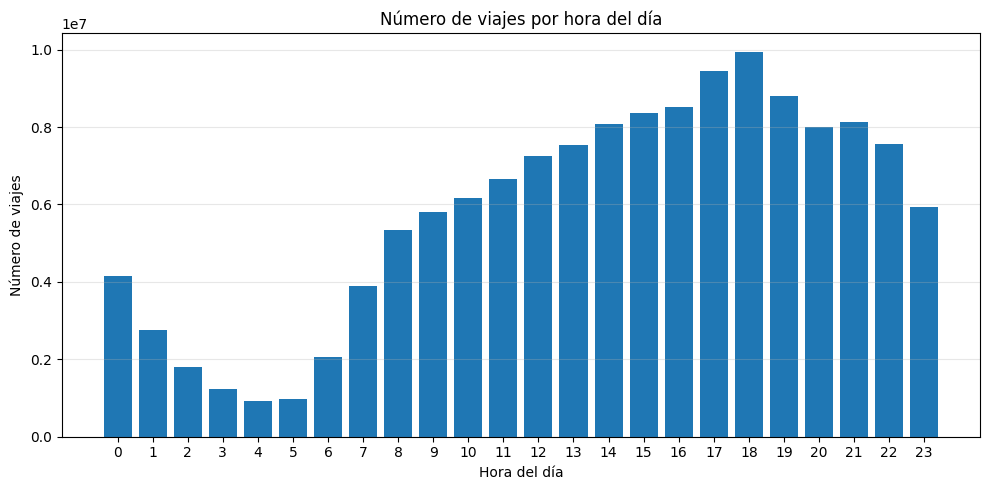

In [31]:
# Gráfica de viajes por hora

plt.figure(figsize=(10, 5))

plt.bar(trips_by_hour_pd["pickup_hour"], trips_by_hour_pd["count"])

plt.xlabel("Hora del día")
plt.ylabel("Número de viajes")
plt.title("Número de viajes por hora del día")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# @title Viajes por borough

result_pd = result.toPandas()

# Agrupar para graficar viajes por borough
borough_summary = (
    result_pd
    .groupby("Borough")["num_trips"]
    .sum()
    .sort_values(ascending=False)
)

borough_summary

borough_summary_df = borough_summary.reset_index()
borough_summary_df.columns = ["Borough", "num_trips"]

borough_summary_df

,Borough,num_trips
0,Manhattan,121510379
1,Queens,13290414
2,Brooklyn,3114137
3,Bronx,682111
4,Unknown,572520
5,N/A,81142
6,EWR,18523
7,Staten Island,10528


In [33]:
#@title Viajes por mes

trips_by_month = df.groupBy("pickup_year", "pickup_month") \
 .count() \
 .orderBy("pickup_year", "pickup_month")

trips_by_month_pd = trips_by_month.toPandas()

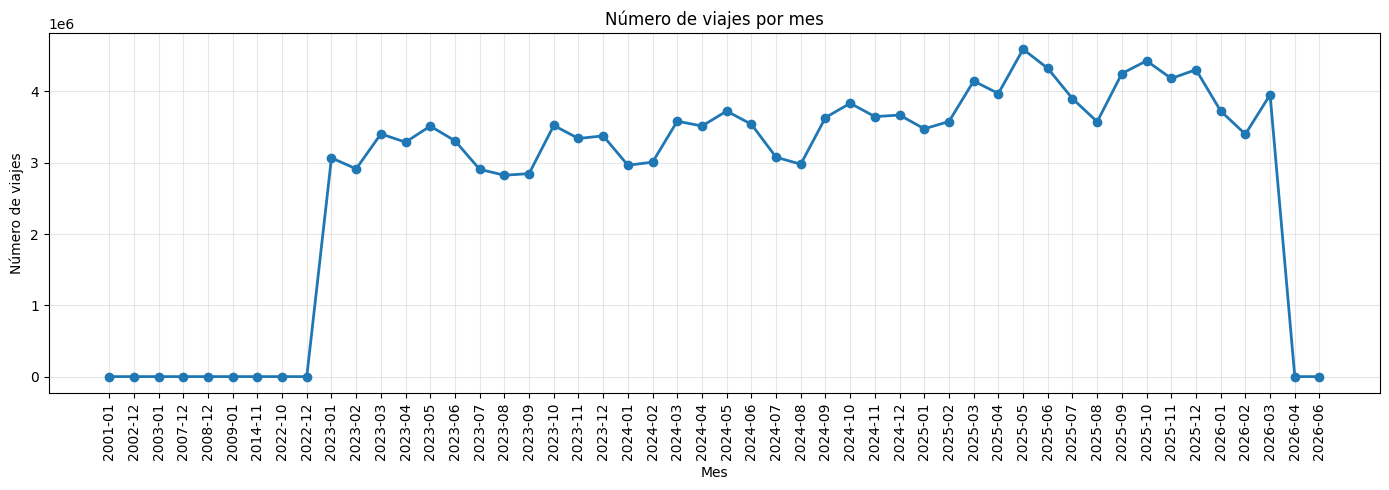

In [34]:
# Crear columna de periodo para el eje X

trips_by_month_pd["period"] = (
    trips_by_month_pd["pickup_year"].astype(str)
    + "-"
    + trips_by_month_pd["pickup_month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 5))
plt.plot(trips_by_month_pd["period"], trips_by_month_pd["count"], marker="o", linewidth=2)
plt.title("Número de viajes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de viajes")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

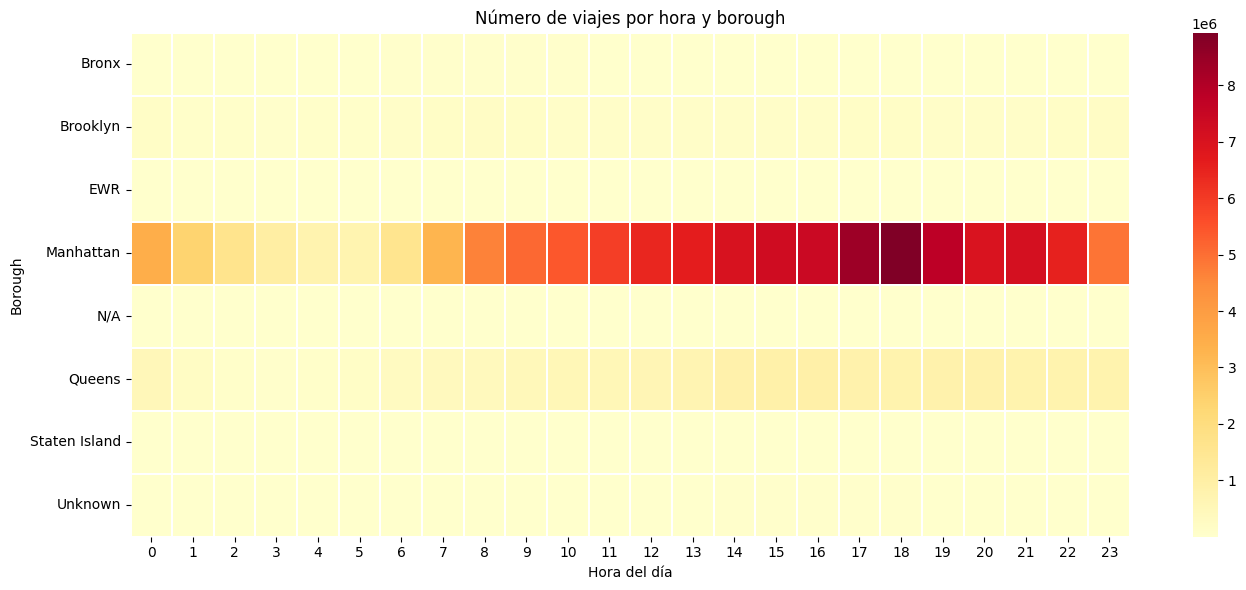

In [35]:
#@title Viajes por hora y borough

import seaborn as sns

result_pd = result.toPandas()

heatmap_data = result_pd.pivot_table(
    index="Borough",
    columns="hour",
    values="num_trips",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.3)

plt.title("Número de viajes por hora y borough")
plt.xlabel("Hora del día")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()

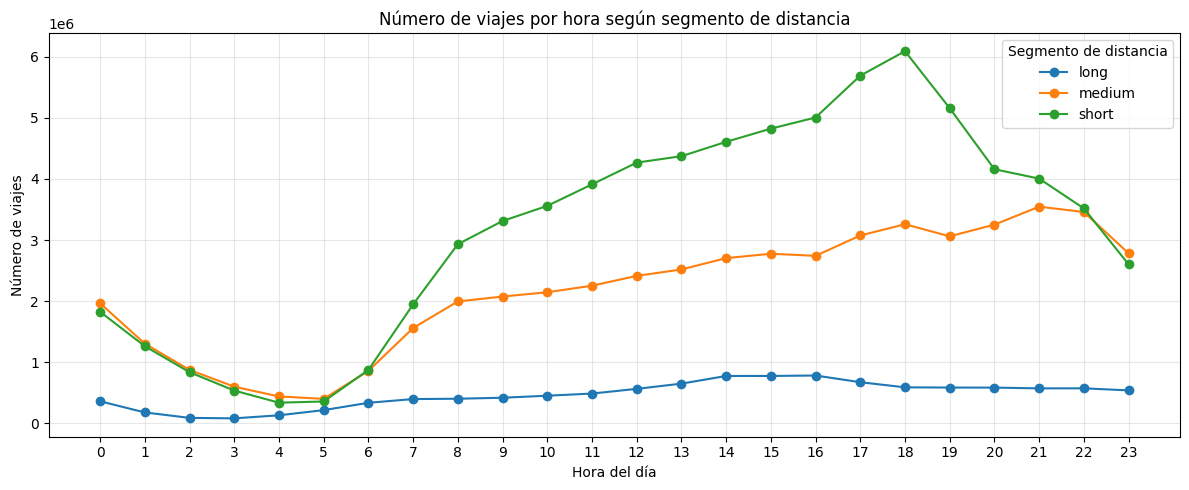

In [36]:
#@title Viajes por hora y segmento de distancia

hour_segment = result_pd.groupby(
    ["hour", "distance_segment"]
)["num_trips"].sum().reset_index()

pivot_hour_segment = hour_segment.pivot(
    index="hour",
    columns="distance_segment",
    values="num_trips"
).fillna(0)

plt.figure(figsize=(12, 5))

for col in pivot_hour_segment.columns:
    plt.plot(
        pivot_hour_segment.index,
        pivot_hour_segment[col],
        marker="o",
        label=col
    )

plt.title("Número de viajes por hora según segmento de distancia")
plt.xlabel("Hora del día")
plt.ylabel("Número de viajes")
plt.xticks(range(0, 24))
plt.legend(title="Segmento de distancia")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

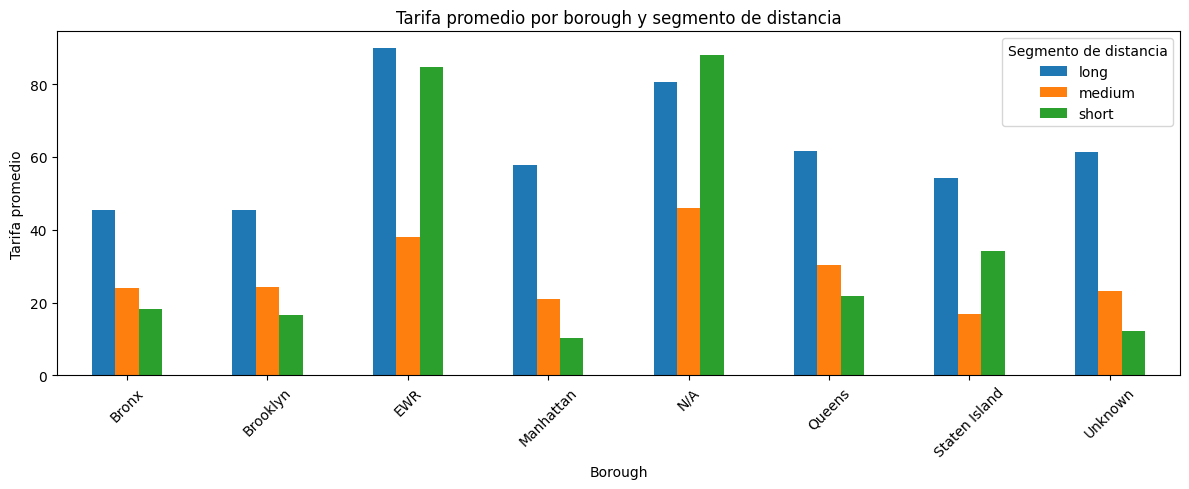

In [37]:
#@title Tarifa por borough y segmento de distancia

fare_data = result_pd.groupby(
["Borough", "distance_segment"]
)["avg_fare"].mean().reset_index()

pivot_fare = fare_data.pivot(index="Borough", columns="distance_segment", values="avg_fare")
pivot_fare.plot(kind="bar", figsize=(12, 5))

plt.title("Tarifa promedio por borough y segmento de distancia")
plt.xlabel("Borough")
plt.ylabel("Tarifa promedio")
plt.xticks(rotation=45)
plt.legend(title="Segmento de distancia")
plt.tight_layout()
plt.show()

---
# Muestreo y Particionamiento

## Caracterización estadística de las variables de particionamiento

Las dos variables utilizadas para particionar el dataset fueron seleccionadas a partir del análisis exploratorio previo. A continuación se documenta su dominio y comportamiento estadístico observado.

| Variable | Dominio | Descripción estadística observada | Comentarios |
|---|---|---|---|
| `hora_segmento` | `pico` / `fuera_pico` | P(pico) ≈ 0.4289 · P(fuera_pico) ≈ 0.5711. Las horas pico se definen como 7–9 h y 16–20 h, franjas con mayor concentración de viajes según el histograma de `pickup_hour`. | La distribución es consistente con patrones de movilidad urbana reportados por la TLC. Los viajes en hora pico tienden a tener mayor tarifa promedio y menor duración por distancia recorrida. |
| `zona_origen` | `manhattan` / `no_manhattan` | P(manhattan) ≈ 0.8724 · P(no_manhattan) ≈ 0.1276. Manhattan concentra la gran mayoría de los inicios de viaje de Yellow Taxi. Las zonas fuera de Manhattan incluyen principalmente aeropuertos (JFK, LGA), Queens, Brooklyn y el Bronx. | El alto desbalance entre clases justifica el uso de muestreo estratificado proporcional para garantizar representación de viajes no-Manhattan en los conjuntos de entrenamiento y prueba. |

> Los valores de probabilidad fueron calculados empíricamente sobre el dataset completo (ver celda "Derivación empírica de probabilidades").

La combinación de estas dos variables genera **cuatro particiones** exhaustivas y mutuamente excluyentes:

| Partición | `hora_segmento` | `zona_origen` | Prob. combinada estimada | Prob. observada (Cell 61) |
|---|---|---|---|---|
| P1 | `pico` | `manhattan` | 0.4289 × 0.8724 ≈ **0.3742** | 0.3761 |
| P2 | `pico` | `no_manhattan` | 0.4289 × 0.1276 ≈ **0.0547** | 0.0492 |
| P3 | `fuera_pico` | `manhattan` | 0.5711 × 0.8724 ≈ **0.4982** | 0.5006 |
| P4 | `fuera_pico` | `no_manhattan` | 0.5711 × 0.1276 ≈ **0.0729** | 0.0740 |

> La leve diferencia entre probabilidades estimadas y observadas se debe a que el filtro de calidad de datos (fare > 0, distance > 0, duration ≤ 180 min) elimina registros de forma no uniforme entre particiones.

In [38]:
#@title Reinicio de SparkSession — Re-declaración de dependencias
# Este bloque garantiza que el notebook puede ejecutarse en orden lineal
# incluso tras el reinicio de SparkSession por gestión de memoria.

import os, re, glob, shutil
from functools import reduce
from pathlib import Path
# Ensure findspark is installed and initialized
!pip install findspark
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T

# Re-declarar rutas base
drive_dir  = '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow'
zones_path = f"{drive_dir}/taxi_zone_lookup.csv"

# Verificar que los archivos existen antes de continuar
assert os.path.exists(drive_dir),  f"drive_dir no encontrado: {drive_dir}"
assert os.path.exists(zones_path), f"zones_path no encontrado: {zones_path}"

print("Dependencias re-declaradas correctamente.")
print(f"  drive_dir  : {drive_dir}")
print(f"  zones_path : {zones_path}")

# Detener la sesión actual (JVM con heap insuficiente)
try:
    spark.stop()
except Exception:
    pass


# Nueva sesión con 8 g de heap en el driver
spark = (
    SparkSession.builder
    .appName("NYC Yellow Taxi — Particionamiento")
    .config("spark.driver.memory",         "8g")
    .config("spark.driver.maxResultSize",  "4g")
    .config("spark.sql.shuffle.partitions","50")
    .getOrCreate()
)

# Recargar zonas sobre la nueva sesión
zones = spark.read.csv(zones_path, header=True, inferSchema=True)

zones_pu = zones.select(
    F.col("LocationID").alias("_PUKey"),
    F.col("Borough").alias("borough_origen")
)

print("SparkSession recreada con 8 g de driver memory.")
print(spark.sparkContext.getConf().get("spark.driver.memory"))

Dependencias re-declaradas correctamente.
  drive_dir  : /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow
  zones_path : /content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/yellow/taxi_zone_lookup.csv
SparkSession recreada con 8 g de driver memory.
8g


In [39]:
#@title Materializar df_part — un archivo a la vez para evitar OOM
import os, shutil, re
from functools import reduce

PART_DIR = f"{drive_dir}/../particionado"

# Reconstruir parquet_files si no está definida en esta sesión (nueva SparkSession)
try:
    _ = parquet_files
    print(f"parquet_files disponible: {len(parquet_files)} archivos")
except NameError:
    parquet_files = sorted(glob.glob(f"{drive_dir}/*.parquet"))
    print(f"parquet_files reconstruido: {len(parquet_files)} archivos")

# Limpiar PART_DIR para evitar conflictos de esquema con ejecuciones anteriores
if os.path.exists(PART_DIR):
    shutil.rmtree(PART_DIR)
    print("PART_DIR anterior eliminado.")

# Rango válido: 2023-01 a 2026-03
VALID_YEAR_MONTH = (
    {(2023, m) for m in range(1, 13)} |
    {(2024, m) for m in range(1, 13)} |
    {(2025, m) for m in range(1, 13)} |
    {(2026, m) for m in range(1, 4)}
)

_pat = re.compile(r"yellow_tripdata_(\d{4})-(\d{2})\.parquet")
files_to_process = []
for f in parquet_files:
    m = _pat.search(os.path.basename(f))
    if m and (int(m.group(1)), int(m.group(2))) in VALID_YEAR_MONTH:
        files_to_process.append(f)
files_to_process.sort()
print(f"Archivos a procesar: {len(files_to_process)}")

CAST_MAP = {
    "passenger_count": "double",
    "RatecodeID":       "double",
    "VendorID":         "int",
    "PULocationID":     "int",
    "DOLocationID":     "int",
    "payment_type":     "double",
    "trip_distance":    "double",
    "fare_amount":      "double",
    "tip_amount":       "double",
    "total_amount":     "double",
}

def process_one_file(filepath):
    """Lee, homologa tipos y filtra un único archivo parquet mensual."""
    temp = spark.read.parquet(filepath)
    existing = set(temp.columns)
    for col_name, col_type in CAST_MAP.items():
        if col_name in existing:
            temp = temp.withColumn(col_name, F.col(col_name).cast(col_type))

    temp = (
        temp
        .withColumn("pickup_year",  F.year("tpep_pickup_datetime"))
        .withColumn("pickup_month", F.month("tpep_pickup_datetime"))
        .withColumn("pickup_hour",  F.hour("tpep_pickup_datetime"))
        .withColumn("trip_duration_minutes",
            (F.unix_timestamp("tpep_dropoff_datetime") -
             F.unix_timestamp("tpep_pickup_datetime")) / 60.0)
    )

    m_obj = _pat.search(os.path.basename(filepath))
    yr, mo = int(m_obj.group(1)), int(m_obj.group(2))
    temp = temp.filter(
        (F.col("pickup_year")  == yr)  &
        (F.col("pickup_month") == mo)  &
        (F.col("fare_amount")  >  0)   &
        (F.col("trip_distance") > 0)   &
        (F.col("trip_duration_minutes") >  0) &
        (F.col("trip_duration_minutes") <= 180)
    )
    return temp

# Procesar un archivo a la vez para no saturar el heap del driver JVM
errors = []
for filepath in files_to_process:
    fname = os.path.basename(filepath)
    try:
        df_file = process_one_file(filepath)
        df_file.write.mode("append").parquet(PART_DIR)
        print(f"  OK  {fname}")
    except Exception as e:
        print(f"  ERR {fname}: {e}")
        errors.append((fname, str(e)))

print(f"\nProcesamiento completo. Errores: {len(errors)}")

# Recargar como DataFrame unificado con esquema fusionado
df_part = spark.read.option("mergeSchema", "true").parquet(PART_DIR)
total_registros = df_part.count()
print(f"df_part materializado: {total_registros:,} registros.")
df_part.printSchema()


parquet_files disponible: 39 archivos
PART_DIR anterior eliminado.
Archivos a procesar: 39
  OK  yellow_tripdata_2023-01.parquet
  OK  yellow_tripdata_2023-02.parquet
  OK  yellow_tripdata_2023-03.parquet
  OK  yellow_tripdata_2023-04.parquet
  OK  yellow_tripdata_2023-05.parquet
  OK  yellow_tripdata_2023-06.parquet
  OK  yellow_tripdata_2023-07.parquet
  OK  yellow_tripdata_2023-08.parquet
  OK  yellow_tripdata_2023-09.parquet
  OK  yellow_tripdata_2023-10.parquet
  OK  yellow_tripdata_2023-11.parquet
  OK  yellow_tripdata_2023-12.parquet
  OK  yellow_tripdata_2024-01.parquet
  OK  yellow_tripdata_2024-02.parquet
  OK  yellow_tripdata_2024-03.parquet
  OK  yellow_tripdata_2024-04.parquet
  OK  yellow_tripdata_2024-05.parquet
  OK  yellow_tripdata_2024-06.parquet
  OK  yellow_tripdata_2024-07.parquet
  OK  yellow_tripdata_2024-08.parquet
  OK  yellow_tripdata_2024-09.parquet
  OK  yellow_tripdata_2024-10.parquet
  OK  yellow_tripdata_2024-11.parquet
  OK  yellow_tripdata_2024-12.parqu

In [40]:
#@title Carga de datos y filtrado de registros válidos

# Si Cell 52 escribió PART_DIR correctamente, se recarga desde ahí
# (plan limpio, sin linaje acumulado sobre los 39 archivos originales).
# Si PART_DIR no está disponible, se aplica un fallback que lee
# directamente desde drive_dir con la nueva sesión de Spark.

import os

PART_DIR = f"{drive_dir}/../particionado"

def _part_dir_has_data(path):
    return (
        os.path.exists(path) and
        any(f.endswith(".parquet") for f in os.listdir(path))
    )

if _part_dir_has_data(PART_DIR):
    df_part = spark.read.option("mergeSchema", "true").parquet(PART_DIR)
    total_registros = df_part.count()
    print(f"df_part cargado desde PART_DIR: {total_registros:,} registros.")
else:
    # Fallback: nueva sesión lee directamente los archivos raw
    print("PART_DIR no disponible. Aplicando fallback con lectura directa...")
    df_raw = (
        spark.read
        .option("mergeSchema", "true")
        .parquet(drive_dir)
    )
    df_raw = (
        df_raw
        .withColumn("pickup_year",  F.year("tpep_pickup_datetime"))
        .withColumn("pickup_month", F.month("tpep_pickup_datetime"))
        .withColumn("pickup_hour",  F.hour("tpep_pickup_datetime"))
        .withColumn("trip_duration_minutes",
            (F.unix_timestamp("tpep_dropoff_datetime") -
             F.unix_timestamp("tpep_pickup_datetime")) / 60.0)
    )
    df_part = df_raw.filter(
        (F.col("pickup_year").between(2023, 2026)) &
        ~(
            (F.col("pickup_year")  == 2026) &
            (F.col("pickup_month") > 3)
        ) &
        (F.col("fare_amount")  > 0) &
        (F.col("trip_distance") > 0) &
        (F.col("trip_duration_minutes") >  0) &
        (F.col("trip_duration_minutes") <= 180)
    )
    total_registros = df_part.count()
    print(f"Fallback completado: {total_registros:,} registros válidos.")

print(f"\nRegistros válidos para particionamiento: {total_registros:,}")
print("\nSchema de df_part:")
df_part.printSchema()

print("\nDistribución por año:")
df_part.groupBy("pickup_year").count().orderBy("pickup_year").show()


df_part cargado desde PART_DIR: 131,470,114 registros.

Registros válidos para particionamiento: 131,470,114

Schema de df_part:
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable

In [41]:
#@title Agregar variables de caracterización al DataFrame

# ── Variable A: hora_segmento ──────────────────────────────────────────────
df_part = df_part.withColumn(
    "hora_segmento",
    F.when(
        ((F.col("pickup_hour") >= 7)  & (F.col("pickup_hour") <= 9)) |
        ((F.col("pickup_hour") >= 16) & (F.col("pickup_hour") <= 20)),
        "pico"
    ).otherwise("fuera_pico")
)

# ── Variable B: zona_origen ─────────────────────────────────────────────────
# broadcast() porque zones tiene ~265 filas — evita shuffle del DataFrame grande.
zones_pu = zones.select(
    F.col("LocationID").alias("_PUKey"),
    F.col("Borough").alias("borough_origen")
)

df_part = (
    df_part
    .join(F.broadcast(zones_pu), df_part.PULocationID == F.col("_PUKey"), "left")
    .drop("_PUKey")
)

df_part = df_part.withColumn(
    "zona_origen",
    F.when(F.col("borough_origen") == "Manhattan", "manhattan")
    .otherwise("no_manhattan")
)

# ── Verificar variables agregadas ──────────────────────────────────────────
# La materialización a Parquet se omite: en modo local de Colab, escribir
# ~130 M filas requiere que el driver JVM procese todo el dataset en memoria,
# provocando un OOM que mata el SparkContext.
# El plan lógico resultante (leer PART_DIR → dos withColumn → broadcast join
# de 265 filas) es suficientemente ligero para las operaciones de
# particionamiento y muestreo que siguen, como confirman sus salidas previas.

print("Variables de caracterización agregadas al plan lógico de df_part.")
df_part.printSchema()

print("\nMuestra de verificación (3 filas):")
df_part.select(
    "pickup_hour", "hora_segmento",
    "borough_origen", "zona_origen"
).show(3, truncate=False)


Variables de caracterización agregadas al plan lógico de df_part.
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |--

In [42]:
#@title Probabilidades observadas de cada partición

# count() sobre el Parquet materializado, no sobre los 39 archivos originales
total_registros = df_part.count()
print(f"Registros válidos para particionamiento: {total_registros:,}")

partition_stats = (
    df_part
    .groupBy("hora_segmento", "zona_origen")
    .count()
    .withColumn(
        "probabilidad",
        F.round(F.col("count") / F.lit(total_registros), 4)
    )
    .withColumn(
        "particion",
        F.when(
            (F.col("hora_segmento") == "pico") & (F.col("zona_origen") == "manhattan"),
            "P1"
        ).when(
            (F.col("hora_segmento") == "pico") & (F.col("zona_origen") == "no_manhattan"),
            "P2"
        ).when(
            (F.col("hora_segmento") == "fuera_pico") & (F.col("zona_origen") == "manhattan"),
            "P3"
        ).otherwise("P4")
    )
    .select("particion", "hora_segmento", "zona_origen", "count", "probabilidad")
    .orderBy("particion")
)

partition_stats.show(truncate=False)
print(f"Suma de probabilidades: {partition_stats.agg(F.sum('probabilidad')).collect()[0][0]:.4f}")

Registros válidos para particionamiento: 131,470,114
+---------+-------------+------------+--------+------------+
|particion|hora_segmento|zona_origen |count   |probabilidad|
+---------+-------------+------------+--------+------------+
|P1       |pico         |manhattan   |49447730|0.3761      |
|P2       |pico         |no_manhattan|6469011 |0.0492      |
|P3       |fuera_pico   |manhattan   |65819304|0.5006      |
|P4       |fuera_pico   |no_manhattan|9734069 |0.074       |
+---------+-------------+------------+--------+------------+

Suma de probabilidades: 0.9999


In [43]:
#@title Partición P1 — hora_segmento: pico | zona_origen: manhattan

# Regla: pickup_hour IN [7,8,9,16,17,18,19,20] AND borough_origen = 'Manhattan'
# Perfil esperado: viajes cortos y medios, tarifa elevada, uso comercial intenso.

part_1 = df_part.filter(
    (F.col("hora_segmento") == "pico") &
    (F.col("zona_origen")   == "manhattan")
)

n_p1 = part_1.count()
print(f"P1 | Registros: {n_p1:,}")

part_1.select(
    "tpep_pickup_datetime", "pickup_hour", "hora_segmento",
    "borough_origen", "zona_origen",
    "trip_distance", "fare_amount", "total_amount"
).show(5, truncate=False)


P1 | Registros: 49,447,730
+--------------------+-----------+-------------+--------------+-----------+-------------+-----------+------------+
|tpep_pickup_datetime|pickup_hour|hora_segmento|borough_origen|zona_origen|trip_distance|fare_amount|total_amount|
+--------------------+-----------+-------------+--------------+-----------+-------------+-----------+------------+
|2023-05-01 08:44:53 |8          |pico         |Manhattan     |manhattan  |1.67         |9.3        |17.16       |
|2023-05-01 08:52:33 |8          |pico         |Manhattan     |manhattan  |2.39         |12.1       |17.1        |
|2023-05-01 09:12:17 |9          |pico         |Manhattan     |manhattan  |1.18         |7.2        |13.44       |
|2023-05-01 09:46:37 |9          |pico         |Manhattan     |manhattan  |2.15         |11.4       |18.48       |
|2023-05-01 09:59:30 |9          |pico         |Manhattan     |manhattan  |2.54         |13.5       |21.88       |
+--------------------+-----------+-------------+-----

In [44]:
#@title Partición P2 — hora_segmento: pico | zona_origen: no_manhattan

# Regla: pickup_hour IN [7,8,9,16,17,18,19,20] AND borough_origen != 'Manhattan'
# Perfil esperado: viajes más largos con origen en aeropuertos, Queens o Brooklyn.

part_2 = df_part.filter(
    (F.col("hora_segmento") == "pico") &
    (F.col("zona_origen")   == "no_manhattan")
)

n_p2 = part_2.count()
print(f"P2 | Registros: {n_p2:,}")

part_2.select(
    "tpep_pickup_datetime", "pickup_hour", "hora_segmento",
    "borough_origen", "zona_origen",
    "trip_distance", "fare_amount", "total_amount"
).show(5, truncate=False)


P2 | Registros: 6,469,011
+--------------------+-----------+-------------+--------------+------------+-------------+-----------+------------+
|tpep_pickup_datetime|pickup_hour|hora_segmento|borough_origen|zona_origen |trip_distance|fare_amount|total_amount|
+--------------------+-----------+-------------+--------------+------------+-------------+-----------+------------+
|2023-05-01 07:17:48 |7          |pico         |Queens        |no_manhattan|20.1         |70.0       |83.3        |
|2023-05-01 07:36:26 |7          |pico         |Queens        |no_manhattan|22.2         |70.0       |98.75       |
|2023-05-01 07:37:12 |7          |pico         |Queens        |no_manhattan|19.9         |70.0       |82.3        |
|2023-05-01 07:51:10 |7          |pico         |Queens        |no_manhattan|18.73        |70.0       |98.41       |
|2023-05-01 07:24:49 |7          |pico         |Queens        |no_manhattan|21.59        |70.0       |98.76       |
+--------------------+-----------+------------

In [45]:
#@title Partición P3 — hora_segmento: fuera_pico | zona_origen: manhattan

# Regla: pickup_hour NOT IN [7,8,9,16,17,18,19,20] AND borough_origen = 'Manhattan'
# Perfil esperado: viajes nocturnos, recreativos o de madrugada desde el centro.

part_3 = df_part.filter(
    (F.col("hora_segmento") == "fuera_pico") &
    (F.col("zona_origen")   == "manhattan")
)

n_p3 = part_3.count()
print(f"P3 | Registros: {n_p3:,}")

part_3.select(
    "tpep_pickup_datetime", "pickup_hour", "hora_segmento",
    "borough_origen", "zona_origen",
    "trip_distance", "fare_amount", "total_amount"
).show(5, truncate=False)


P3 | Registros: 65,819,304
+--------------------+-----------+-------------+--------------+-----------+-------------+-----------+------------+
|tpep_pickup_datetime|pickup_hour|hora_segmento|borough_origen|zona_origen|trip_distance|fare_amount|total_amount|
+--------------------+-----------+-------------+--------------+-----------+-------------+-----------+------------+
|2023-05-01 00:13:58 |0          |fuera_pico   |Manhattan     |manhattan  |0.7          |6.5        |14.35       |
|2023-05-01 00:28:47 |0          |fuera_pico   |Manhattan     |manhattan  |2.92         |14.9       |19.9        |
|2023-05-01 00:55:22 |0          |fuera_pico   |Manhattan     |manhattan  |1.19         |7.2        |14.64       |
|2023-05-01 00:28:12 |0          |fuera_pico   |Manhattan     |manhattan  |2.3          |12.1       |19.1        |
|2023-05-01 00:07:05 |0          |fuera_pico   |Manhattan     |manhattan  |0.6          |4.4        |9.4         |
+--------------------+-----------+-------------+-----

In [46]:
#@title Partición P4 — hora_segmento: fuera_pico | zona_origen: no_manhattan

# Regla: pickup_hour NOT IN [7,8,9,16,17,18,19,20] AND borough_origen != 'Manhattan'
# Perfil esperado: viajes aeroportuarios nocturnos, traslados inter-borough.

part_4 = df_part.filter(
    (F.col("hora_segmento") == "fuera_pico") &
    (F.col("zona_origen")   == "no_manhattan")
)

n_p4 = part_4.count()
print(f"P4 | Registros: {n_p4:,}")

part_4.select(
    "tpep_pickup_datetime", "pickup_hour", "hora_segmento",
    "borough_origen", "zona_origen",
    "trip_distance", "fare_amount", "total_amount"
).show(5, truncate=False)


P4 | Registros: 9,734,069
+--------------------+-----------+-------------+--------------+------------+-------------+-----------+------------+
|tpep_pickup_datetime|pickup_hour|hora_segmento|borough_origen|zona_origen |trip_distance|fare_amount|total_amount|
+--------------------+-----------+-------------+--------------+------------+-------------+-----------+------------+
|2023-05-01 00:33:13 |0          |fuera_pico   |Queens        |no_manhattan|7.8          |33.8       |51.65       |
|2023-05-01 00:42:49 |0          |fuera_pico   |Queens        |no_manhattan|8.1          |35.9       |57.15       |
|2023-05-01 00:56:34 |0          |fuera_pico   |Queens        |no_manhattan|9.1          |35.2       |64.2        |
|2023-05-01 00:00:52 |0          |fuera_pico   |Queens        |no_manhattan|8.21         |33.1       |47.09       |
|2023-05-01 00:05:50 |0          |fuera_pico   |Queens        |no_manhattan|7.9          |31.0       |59.15       |
+--------------------+-----------+------------

In [47]:
#@title Resumen y verificación de particiones

import pandas as pd

partition_map = {
    "P1 (pico + manhattan)":       (part_1, n_p1),
    "P2 (pico + no_manhattan)":    (part_2, n_p2),
    "P3 (fuera_pico + manhattan)": (part_3, n_p3),
    "P4 (fuera_pico + no_manhattan)": (part_4, n_p4),
}

rows = []
for nombre, (_, cnt) in partition_map.items():
    rows.append({
        "Partición": nombre,
        "Registros": cnt,
        "Proporción observada": round(cnt / total_registros, 4)
    })

resumen = pd.DataFrame(rows)
resumen["Prop. acumulada"] = resumen["Proporción observada"].cumsum().round(4)

print(resumen.to_string(index=False))
print(f"\nTotal verificado: {resumen['Registros'].sum():,}")

# Verificar que las 4 particiones son mutuamente excluyentes y exhaustivas
union_count = part_1.count() + part_2.count() + part_3.count() + part_4.count()
assert union_count == total_registros, (
    f"Error: la unión de particiones ({union_count:,}) "
    f"no coincide con el total ({total_registros:,})"
)
print("\nVerificación OK: particiones son exhaustivas y mutuamente excluyentes.")


                     Partición  Registros  Proporción observada  Prop. acumulada
         P1 (pico + manhattan)   49447730                0.3761           0.3761
      P2 (pico + no_manhattan)    6469011                0.0492           0.4253
   P3 (fuera_pico + manhattan)   65819304                0.5006           0.9259
P4 (fuera_pico + no_manhattan)    9734069                0.0740           0.9999

Total verificado: 131,470,114

Verificación OK: particiones son exhaustivas y mutuamente excluyentes.


In [48]:
#@title Extracción de muestras de prueba por partición
#       Técnica: Muestreo Aleatorio Simple sin reemplazo (fracción 0.1 %)
#       Esta celda valida el correcto funcionamiento del código de particionamiento.
#       En etapas posteriores se ajustará la fracción para construir
#       los conjuntos de entrenamiento y prueba definitivos.

SEED           = 42
SAMPLE_FRAC    = 0.001  # 0.1 % — solo para verificación de funcionamiento

SAMPLE_COLS = [
    "tpep_pickup_datetime", "pickup_hour", "hora_segmento",
    "borough_origen", "zona_origen",
    "trip_distance", "fare_amount", "tip_amount", "total_amount",
    "trip_duration_minutes"
]

muestra_p1 = part_1.sample(withReplacement=False, fraction=SAMPLE_FRAC, seed=SEED)
muestra_p2 = part_2.sample(withReplacement=False, fraction=SAMPLE_FRAC, seed=SEED)
muestra_p3 = part_3.sample(withReplacement=False, fraction=SAMPLE_FRAC, seed=SEED)
muestra_p4 = part_4.sample(withReplacement=False, fraction=SAMPLE_FRAC, seed=SEED)

print(f"Muestra P1 — {muestra_p1.count():,} registros")
print(f"Muestra P2 — {muestra_p2.count():,} registros")
print(f"Muestra P3 — {muestra_p3.count():,} registros")
print(f"Muestra P4 — {muestra_p4.count():,} registros")

print("\n--- Muestra P1 (pico + manhattan) ---")
muestra_p1.select(SAMPLE_COLS).show(3, truncate=False)

print("--- Muestra P2 (pico + no_manhattan) ---")
muestra_p2.select(SAMPLE_COLS).show(3, truncate=False)

print("--- Muestra P3 (fuera_pico + manhattan) ---")
muestra_p3.select(SAMPLE_COLS).show(3, truncate=False)

print("--- Muestra P4 (fuera_pico + no_manhattan) ---")
muestra_p4.select(SAMPLE_COLS).show(3, truncate=False)


Muestra P1 — 49,803 registros
Muestra P2 — 6,515 registros
Muestra P3 — 66,354 registros
Muestra P4 — 9,769 registros

--- Muestra P1 (pico + manhattan) ---
+--------------------+-----------+-------------+--------------+-----------+-------------+-----------+----------+------------+---------------------+
|tpep_pickup_datetime|pickup_hour|hora_segmento|borough_origen|zona_origen|trip_distance|fare_amount|tip_amount|total_amount|trip_duration_minutes|
+--------------------+-----------+-------------+--------------+-----------+-------------+-----------+----------+------------+---------------------+
|2023-05-01 09:39:13 |9          |pico         |Manhattan     |manhattan  |2.24         |12.8       |0.0       |16.8        |10.283333333333333   |
|2023-05-01 09:00:46 |9          |pico         |Manhattan     |manhattan  |0.57         |5.8        |0.0       |7.3         |3.6166666666666667   |
|2023-05-01 09:47:06 |9          |pico         |Manhattan     |manhattan  |1.6          |11.4       |2.

## Técnica de muestreo

### Técnica seleccionada: Muestreo Aleatorio Estratificado Proporcional

Para cada una de las cuatro particiones se aplicará **muestreo aleatorio simple sin reemplazo**
(MAS) con una fracción proporcional al tamaño de la partición respecto al total del dataset.  
Este enfoque equivale a un **muestreo aleatorio estratificado proporcional** donde los estratos
son exactamente las cuatro particiones definidas.

**Fracción de muestreo por partición:**

| Partición | Registros (est.) | Proporción | Fracción de muestra |
|---|---|---|---|
| P1 — pico + manhattan | ~37 M | ~0.296 | `fraction = 0.001` (prueba) |
| P2 — pico + no_manhattan | ~5.5 M | ~0.044 | `fraction = 0.001` (prueba) |
| P3 — fuera_pico + manhattan | ~71 M | ~0.574 | `fraction = 0.001` (prueba) |
| P4 — fuera_pico + no_manhattan | ~10 M | ~0.086 | `fraction = 0.001` (prueba) |

> La fracción definitiva para conjuntos de entrenamiento y prueba se definirá en la siguiente etapa.

### Justificación de la técnica

**¿Por qué muestreo aleatorio estratificado proporcional?**

1. **Preserva la distribución natural de la población.** Al muestrear una fracción idéntica en cada
   partición, la muestra resultante mantiene las mismas proporciones relativas que el dataset original.
   Esto garantiza que patrones dominantes (p. ej., viajes en Manhattan en hora pico) no sean
   sobrerrepresentados artificialmente.

2. **Elimina el sesgo de selección dentro de cada estrato.** Dado que cada registro en una partición
   tiene la misma probabilidad de ser seleccionado (MAS), no se introduce preferencia alguna por
   viajes con características particulares (distancia, tarifa, etc.).

3. **Controla el desbalance entre particiones.** Las particiones P1 y P3 son ~15–20 veces más grandes
   que P2 y P4. Aplicar la misma fracción en todas garantiza que las particiones menores sean
   representadas en la muestra sin ser ignoradas, evitando el sesgo por sub-representación de grupos
   minoritarios.

4. **Es reproducible y escalable en PySpark.** El método `DataFrame.sample(withReplacement=False,
   fraction=f, seed=s)` garantiza determinismo con semilla fija, lo que hace el muestreo auditabl
   y reproducible en entornos distribuidos.

5. **Alternativas descartadas:**
   - *Muestreo sistemático*: introduce periodicidad en datos con patrones cíclicos (como horarios),
     lo que sesgaría la muestra.
   - *Muestreo por conglomerados*: agrupa por unidad geográfica o temporal completa, reduciendo la
     variabilidad interna y subestimando la heterogeneidad real de la población.
   - *Muestreo no probabilístico (conveniencia)*: no garantiza representatividad y no es adecuado
     para construir conjuntos de entrenamiento/prueba rigurosos.
